# 변수 선정 및 의사결정나무

장르별로 어떤 변수(오디오/가사/시각)가 조회수를 가장 잘 설명하는지 의사결정나무·랜덤포레스트로 탐색하고, 최종 모델링에 쓸 변수를 선정하는 노트북입니다.

In [1]:
# 0. 설정: 라이브러리, 한글 폰트, 데이터 경로 (basic_eda와 같은 구성)
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings('ignore')

DATA_FILE = Path("../data/data(drop_duplicated).csv")      # 전처리(deduplication)가 만든 분석용 데이터
REFERENCE_DATE = "2026-02-04"                              # 일평균 조회수 계산의 기준일


def set_korean_font():
    """설치된 한글 폰트를 찾아 matplotlib에 적용한다."""
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ['NanumBarunGothic', 'NanumGothic', 'Malgun Gothic', 'AppleGothic', 'Noto Sans CJK KR']:
        if name in installed:
            plt.rcParams['font.family'] = name
            return name
    for path in ['C:/Windows/Fonts/malgun.ttf', '/mnt/c/Windows/Fonts/malgun.ttf']:   # Windows / WSL
        if Path(path).exists():
            for p in (path, path.replace('malgun.ttf', 'malgunbd.ttf')):      # 일반·굵은 글씨체 등록
                if Path(p).exists():
                    font_manager.fontManager.addfont(p)
            name = font_manager.FontProperties(fname=path).get_name()
            plt.rcParams['font.family'] = name
            return name
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")


print("그래프 한글 폰트:", set_korean_font())
plt.rcParams['axes.unicode_minus'] = False

그래프 한글 폰트: Malgun Gothic


In [2]:
# 0-1. 데이터 불러오기: basic_eda와 같은 입력·같은 흐름 (df_final → 분석_df)
df_final = pd.read_csv(DATA_FILE)

# 게시일 기준 경과일수로 일평균 조회수(daily_view_count) 계산 (basic_eda 1-1과 동일)
df_final['api_published_at'] = pd.to_datetime(df_final['api_published_at'], utc=True, format='mixed')
days_diff = (pd.to_datetime(REFERENCE_DATE).tz_localize('UTC') - df_final['api_published_at']).dt.days.clip(lower=1)
df_final['daily_view_count'] = df_final['api_view_count'] / days_diff

# basic_eda 1-1과 같은 이상치 제외
exclude_ids = ['cSqOY5nktfg', 'pOVNGANwcrk', '0RvaJ9hOkw8']
df_final = df_final[~df_final['video_id'].isin(exclude_ids)].copy()

# 분석에 필요한 컬럼 리스트 정의 (basic_eda의 분석_df와 동일)
target_columns = [
    'genie_genre', 'valence_raw', 'arousal_raw', 'valence_normalized', 'arousal_normalized',
    'energy', 'loudness', 'tempo', 'duration_ms',
    'speechiness', 'acoustic_score', 'sentiment_compound',
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'avg_brightness', 'avg_motion', 'avg_r_value', 'avg_g_value', 'avg_b_value',
    'token_count', 'unique_token_ratio', 'repeated_token_ratio',
    'avg_token_length', 'hapax_legomenon', 'hapax_dislegomenon', 'hapax_trislegomenon',
    'unique_tokens_per_line', 'avg_tokens_per_line', 'line_count',
    'punctuation_ratio', 'compression_rate', 'pronoun_frequency',
    'korean_ratio', 'english_ratio', 'daily_view_count'
]

# 새로운 데이터프레임 생성
분석_df = df_final[target_columns].copy()

print(f"데이터 개수: {len(분석_df):,}곡 | 분석_df shape: {분석_df.shape}")

데이터 개수: 2,042곡 | 분석_df shape: (2042, 36)


### 1-1. 의사결정나무 기본 모델 (락 장르)
**분석**: 락 장르만 대상으로 오디오 변수(valence, arousal, acoustic_score, energy)로 의사결정나무(depth=3)를 학습해 조회수(로그값)를 예측.
**결과**: 최상단 분기 기준이 `valence_normalized`(0.549) → 조회수를 가장 강하게 가르는 변수. 예측 조회수가 가장 높은 구간은 valence 0.463~0.469의 좁은 구간이지만 해당 구간은 1곡뿐이라 '골든존'으로 일반화하기는 어려움.

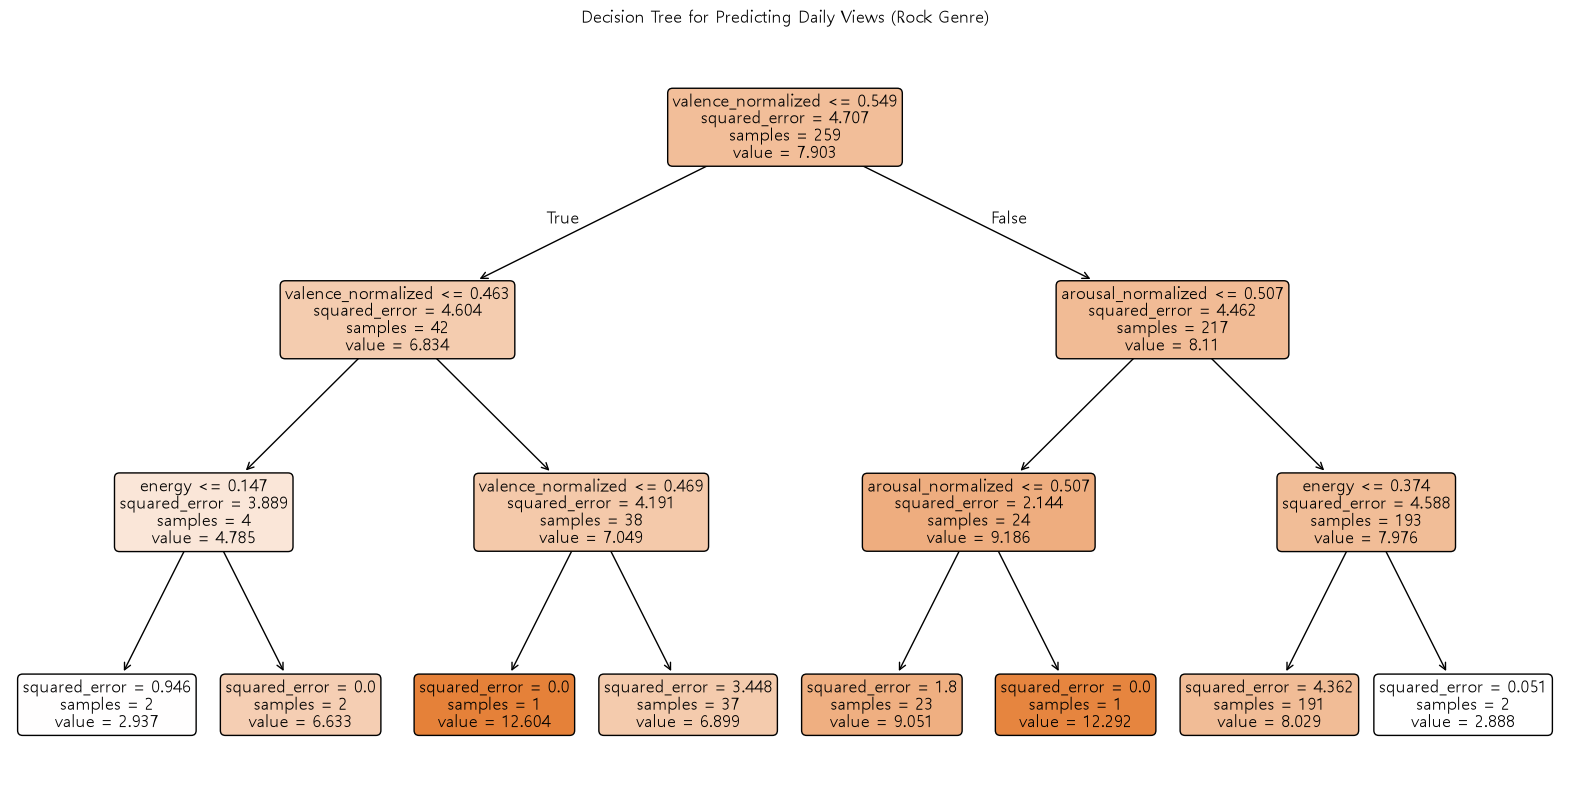

In [3]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. 분석할 데이터 준비 (예: 락 장르)
tree_df = 분석_df[분석_df['genie_genre'] == '락'].dropna()
X = tree_df[['valence_normalized', 'arousal_normalized', 'acoustic_score', 'energy']]
y = np.log1p(tree_df['daily_view_count']) # 조회수 편차 완화를 위해 로그 변환

# 2. 모델 학습 (너무 깊으면 보기 힘드므로 depth 제한)
regr = DecisionTreeRegressor(max_depth=3, random_state=42)
regr.fit(X, y)

# 3. 시각화
plt.figure(figsize=(20, 10))
plot_tree(regr, feature_names=X.columns, filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree for Predicting Daily Views (Rock Genre)")
plt.show()

### 1-2. 가사 변수 포함 '락' vs '팝' 비교
**분석**: 오디오 변수에 가사 변수(korean_ratio, token_count 등)를 추가해 락/팝 각각 의사결정나무를 재학습.
**결과**: 락은 korean_ratio+token_count가 합쳐서 중요도 약 62%(가사 비중이 큼), 팝은 valence_normalized(42%)와 arousal_normalized(37%)가 합쳐서 약 79%로 여전히 우세(가사 변수 token_count 21%보다 분위기가 크게 좌우). 다만 팝은 20곡뿐이라 해석에 주의.

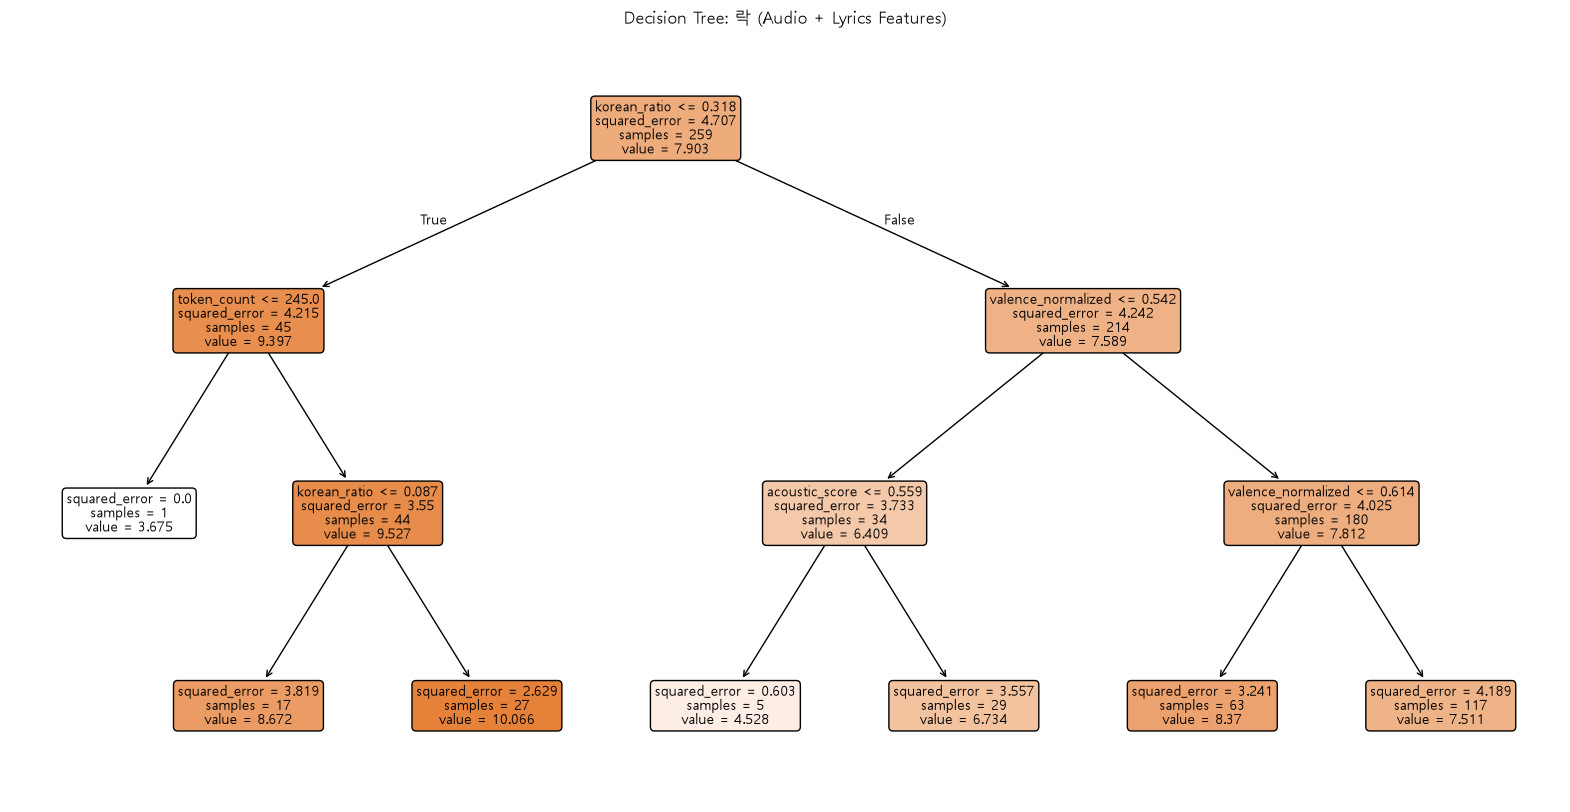

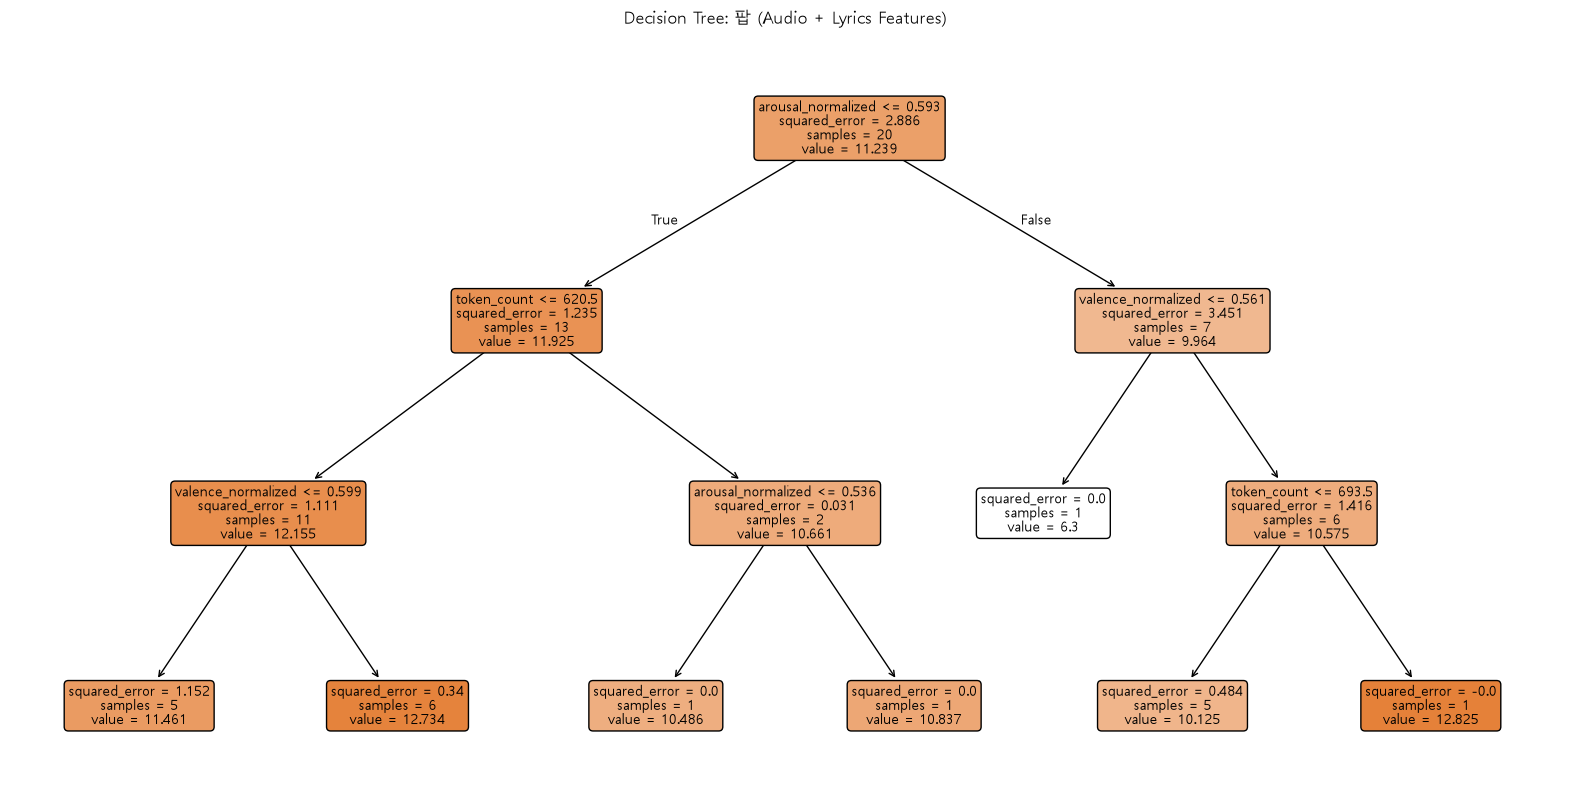

In [4]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 분석에 사용할 확장 변수 리스트
ext_features = ['valence_normalized', 'arousal_normalized', 'acoustic_score',
                'energy', 'korean_ratio', 'token_count']

def compare_genre_tree(df, genre_name):
    target_df = df[df['genie_genre'] == genre_name].dropna()
    X = target_df[ext_features]
    y = np.log1p(target_df['daily_view_count'])

    model = DecisionTreeRegressor(max_depth=3, random_state=42)
    model.fit(X, y)

    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=ext_features, filled=True, rounded=True, fontsize=10)
    plt.title(f"Decision Tree: {genre_name} (Audio + Lyrics Features)")
    plt.show()

    return model, X.columns

# '락'과 '팝' 각각 실행
rock_model, feat_names = compare_genre_tree(분석_df, '락')
pop_model, _ = compare_genre_tree(분석_df, '팝')

### 1-3. 변수 중요도 순위 비교 (락 vs 팝)
**분석**: 두 모델의 `feature_importances_`를 하나의 데이터프레임으로 합쳐 비교.

              Feature  Rock_Importance  Pop_Importance
0        korean_ratio         0.502146        0.000000
1  valence_normalized         0.305944        0.422678
2         token_count         0.118487        0.207461
3      acoustic_score         0.073423        0.000000
4  arousal_normalized         0.000000        0.369861
5              energy         0.000000        0.000000


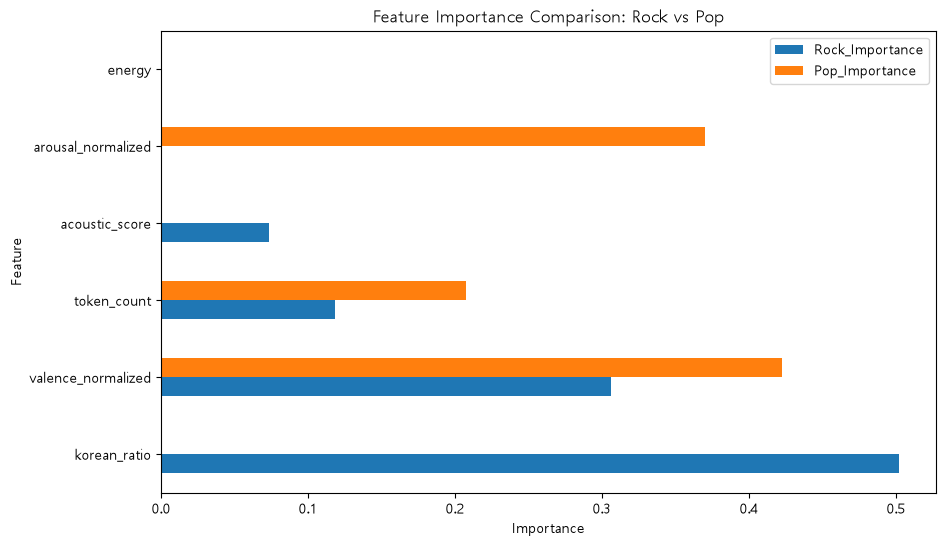

In [5]:
import pandas as pd

def get_importance_df(model, feature_names, genre_name):
    importances = model.feature_importances_
    df = pd.DataFrame({'Feature': feature_names, f'{genre_name}_Importance': importances})
    return df.sort_values(f'{genre_name}_Importance', ascending=False)

# 중요도 추출
rock_imp = get_importance_df(rock_model, feat_names, 'Rock')
pop_imp = get_importance_df(pop_model, feat_names, 'Pop')

# 두 장르 합쳐서 보기
importance_compare = pd.merge(rock_imp, pop_imp, on='Feature')
print(importance_compare)

# 시각화
importance_compare.set_index('Feature').plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance Comparison: Rock vs Pop')
plt.xlabel('Importance')
plt.show()

### 1-4. 발라드 & 랩/힙합 확장 비교
**분석**: 같은 방식으로 발라드, 랩/힙합 장르에도 의사결정나무를 적용해 4개 장르의 변수 중요도를 통합 비교.
**결과 (장르별 핵심 변수)**: 락=korean_ratio·valence·token_count(가사 양/언어비중이 중요, korean_ratio 50%), 팝=valence·arousal·token_count(밝기/각성도가 79% 결정, 20곡), 발라드=korean_ratio·acoustic_score(korean_ratio 67%, acoustic 16%), 랩/힙합=korean_ratio·token_count·energy(korean_ratio 66%).

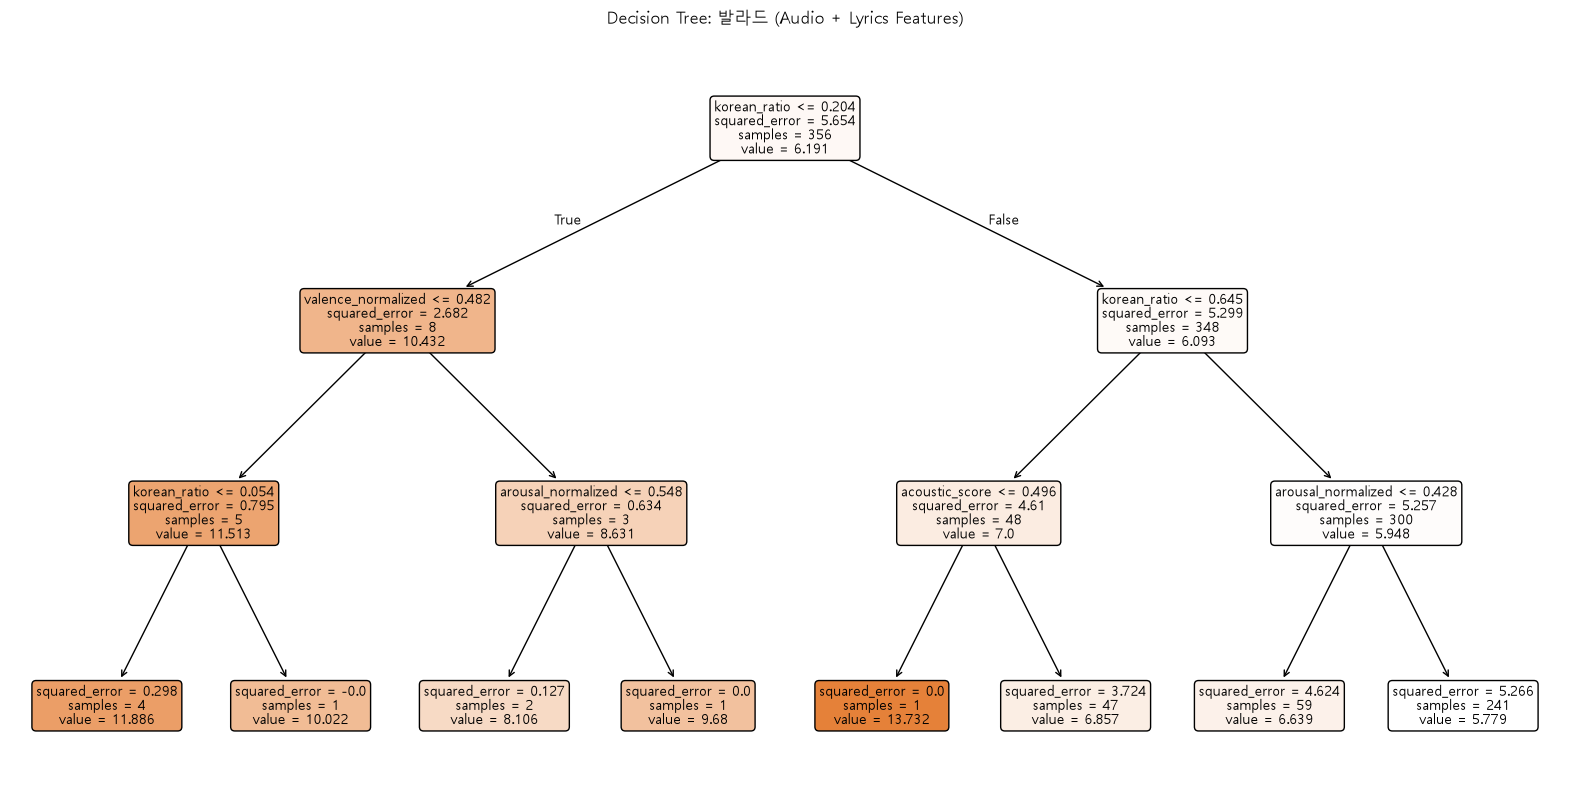

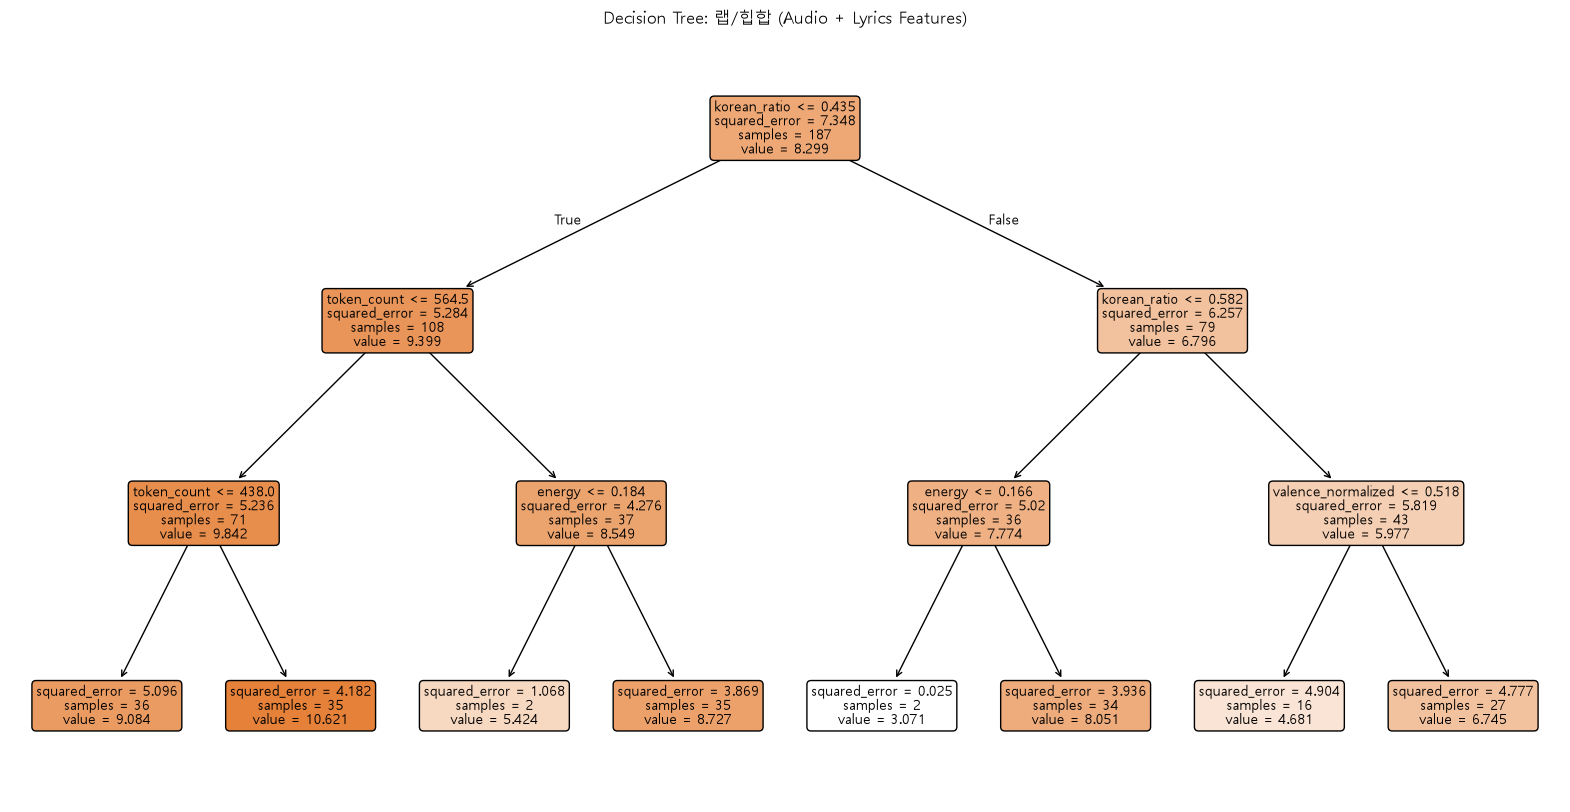

--- 전 장르 핵심 변수 중요도 비교 ---
              Feature  Rock_Importance  Pop_Importance  Ballad_Importance  \
0        korean_ratio         0.502146        0.000000           0.665170   
1  valence_normalized         0.305944        0.422678           0.052911   
2         token_count         0.118487        0.207461           0.000000   
3      acoustic_score         0.073423        0.000000           0.157193   
4  arousal_normalized         0.000000        0.369861           0.124726   
5              energy         0.000000        0.000000           0.000000   

   HipHop_Importance  
0           0.658773  
1           0.075737  
2           0.146112  
3           0.000000  
4           0.000000  
5           0.119377  


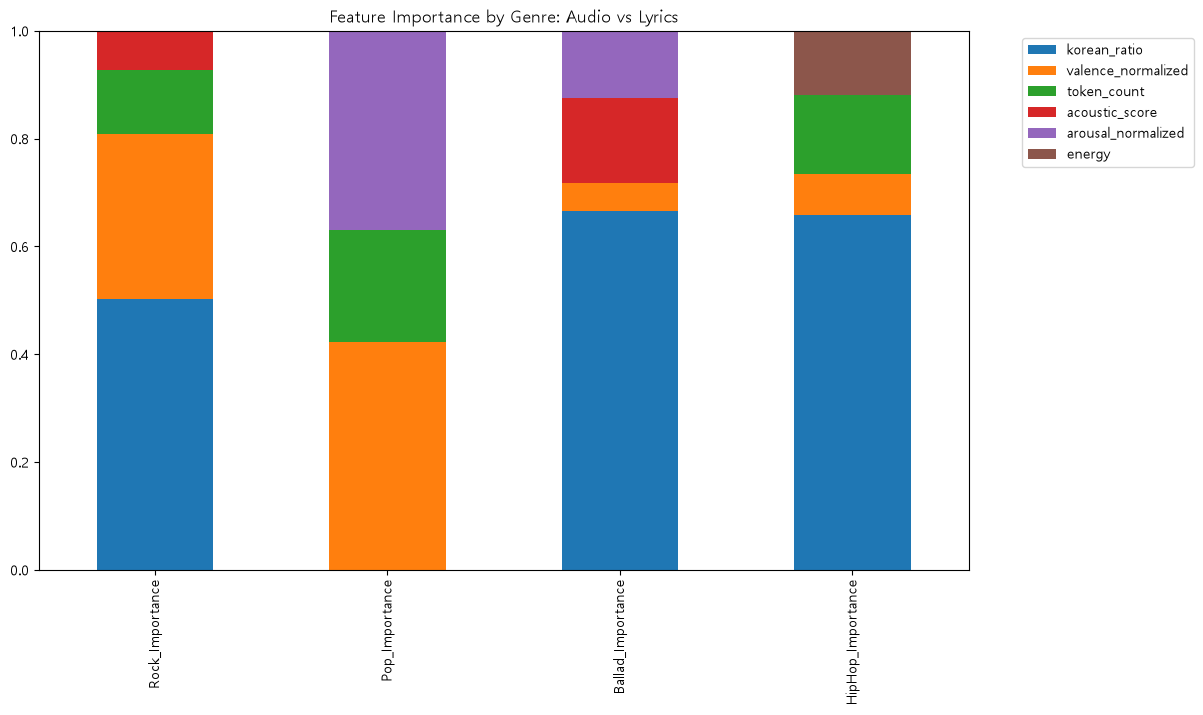

In [6]:
# '발라드'와 '랩/힙합'에 대해서도 의사결정나무 및 중요도 추출
ballad_model, _ = compare_genre_tree(분석_df, '발라드')
hiphop_model, _ = compare_genre_tree(분석_df, '랩/힙합')

# 중요도 비교 데이터프레임 생성
ballad_imp = get_importance_df(ballad_model, feat_names, 'Ballad')
hiphop_imp = get_importance_df(hiphop_model, feat_names, 'HipHop')

# 기존 락/팝 결과와 합치기
total_importance = pd.merge(importance_compare, ballad_imp, on='Feature')
total_importance = pd.merge(total_importance, hiphop_imp, on='Feature')

print("--- 전 장르 핵심 변수 중요도 비교 ---")
print(total_importance)

# 시각화
total_importance.set_index('Feature').T.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Feature Importance by Genre: Audio vs Lyrics')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 1-5. 시각 변수 포함 의사결정나무
**분석**: 오디오+가사 변수에 시각 변수(avg_brightness, avg_motion, RGB, duration_ms(영상 길이))까지 추가한 전체 변수로 의사결정나무를 학습.

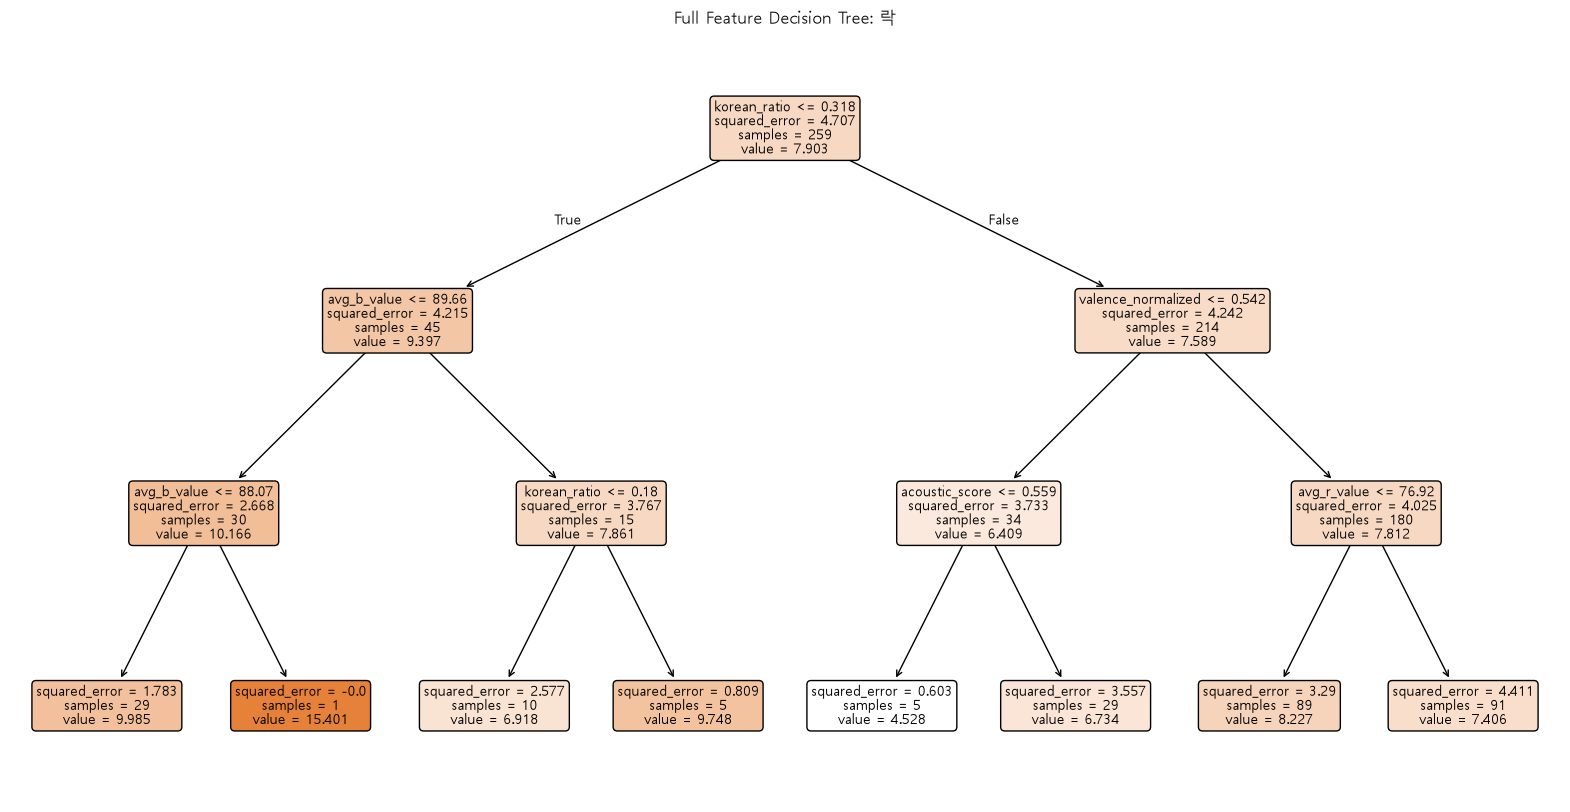

In [7]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# 시각 변수까지 포함한 전체 변수 리스트
all_features = [
    'valence_normalized', 'arousal_normalized', 'acoustic_score', 'energy',
    'korean_ratio', 'token_count', 'avg_brightness', 'avg_motion',
    'avg_r_value', 'avg_g_value', 'avg_b_value', 'duration_ms'
]

def draw_full_tree(df, genre_name):
    target_df = df[df['genie_genre'] == genre_name].dropna()
    X = target_df[all_features]
    y = np.log1p(target_df['daily_view_count'])

    # 시각적 가독성을 위해 깊이는 3으로 제한
    model = DecisionTreeRegressor(max_depth=3, random_state=42)
    model.fit(X, y)

    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=all_features, filled=True, rounded=True, fontsize=10)
    plt.title(f"Full Feature Decision Tree: {genre_name}")
    plt.show()

# 예: 락 장르의 시각 변수 영향력 확인
draw_full_tree(분석_df, '락')

### 1-6. 장르별 가중치 모델 (RandomForest)
**분석**: 4개 장르(락/팝/발라드/랩힙합) 각각에 `RandomForestRegressor`를 학습해 장르 특화 모델을 만듦.

In [8]:
from sklearn.ensemble import RandomForestRegressor

# 장르별로 모델을 저장할 딕셔너리
genre_models = {}

for genre in ['락', '팝', '발라드', '랩/힙합']:
    genre_data = 분석_df[분석_df['genie_genre'] == genre].dropna()
    X = genre_data[ext_features]
    y = np.log1p(genre_data['daily_view_count'])

    # 각 장르에 최적화된 랜덤 포레스트 모델 학습
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    genre_models[genre] = model
    print(f"{genre} 모델 학습 완료 (R² score: {model.score(X, y):.2f})")

락 모델 학습 완료 (R² score: 0.86)
팝 모델 학습 완료 (R² score: 0.84)


발라드 모델 학습 완료 (R² score: 0.86)
랩/힙합 모델 학습 완료 (R² score: 0.89)


### 1-7. 통합 모델 (One-Hot Encoding + Interaction)
**분석**: 장르를 원-핫 인코딩해 전체 데이터를 하나의 RandomForest로 통합 학습하고, 변수 중요도를 확인.

In [9]:
# 1. 원-핫 인코딩 적용
분석_final = pd.get_dummies(분석_df, columns=['genie_genre'])

# 2. 통합 모델용 변수 설정 (오디오 + 가사 + 장르 더미)
features_all = ext_features + [col for col in 분석_final.columns if 'genie_genre_' in col]

X_all = 분석_final[features_all].dropna()
y_all = np.log1p(분석_final.loc[X_all.index, 'daily_view_count'])

# 3. 통합 랜덤 포레스트 모델 학습
total_model = RandomForestRegressor(n_estimators=200, random_state=42)
total_model.fit(X_all, y_all)

# 4. 통합 모델에서의 변수 중요도 확인
final_imp = pd.DataFrame({'Feature': features_all, 'Importance': total_model.feature_importances_})
print(final_imp.sort_values(by='Importance', ascending=False).head(10))

               Feature  Importance
4         korean_ratio    0.310782
0   valence_normalized    0.128703
5          token_count    0.120584
1   arousal_normalized    0.117899
3               energy    0.114716
2       acoustic_score    0.113662
7       genie_genre_댄스    0.042473
8        genie_genre_락    0.011326
12  genie_genre_일렉트로니카    0.008086
10     genie_genre_발라드    0.007271


### 1-8. 최종 변수 선정
**결과 (추천 변수 Top 10)**: `korean_ratio`(통합 중요도 1위 31%, 필수) · `valence_normalized` · `token_count` · `arousal_normalized` · `energy` · `acoustic_score` · `genie_genre`_댄스/일렉트로니카 더미 · `avg_motion` · `line_count` · `english_ratio`(대조군).
※ `avg_motion`, `line_count`, `english_ratio`는 1-7 통합 모델의 입력은 아니지만, 05번 최종 모델에서 직접 또는 파생변수(`speechiness_eng`, `lyric_repetition` 등)로 쓰입니다. 장르 더미는 출력 기준 댄스(0.042) > 락(0.011) > 일렉트로니카(0.008) 순입니다.